In [1]:
import os
import shutil
from pathlib import Path
from typing import List, Literal, Optional, Tuple

import cv2
import dlib
import mediapipe as mp
import numpy as np
from tqdm import tqdm


# ---------------------------------------------------------------------
# Global initialization
# ---------------------------------------------------------------------
PREDICTOR_PATH = "/Users/jocareher/Library/CloudStorage/OneDrive-Personal/Educacion/eLearning/face_detection/weights/shape_predictor_68_face_landmarks.dat"

detector_dlib = dlib.get_frontal_face_detector()
predictor_dlib = dlib.shape_predictor(PREDICTOR_PATH)

mp_face_mesh = mp.solutions.face_mesh
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles


ModelName = Literal["dlib", "mediapipe"]
MediaPipeOutputMode = Literal["subset_68", "full"]


# Commonly used MediaPipe-to-68 subset in conventional 68-point order
LANDMARKS_68_INDICES = [
    162, 234, 93, 58, 172, 136, 149, 148, 152, 377, 378, 365, 397, 288, 323, 454, 389,
    71, 63, 105, 66, 107,
    336, 296, 334, 293, 301,
    168, 197, 5, 4,
    75, 97, 2, 326, 305,
    33, 160, 158, 133, 153, 144,
    362, 385, 387, 263, 373, 380,
    61, 39, 37, 0, 267, 269, 291,
    405, 314, 17, 84, 181,
    78, 82, 13, 312, 308, 317, 14, 87,
]


# ---------------------------------------------------------------------
# IO utilities
# ---------------------------------------------------------------------
def save_labels(
    output_label_path: str,
    detections: List[List[Tuple[float, float]]],
) -> None:
    """
    Save landmark coordinates to a text file.

    Each landmark is written as:
        x y

    Multiple detections in the same image are separated by a blank line.

    Args:
        output_label_path: Destination txt path.
        detections: List of detections, where each detection is a list of
            (x, y) landmark coordinates.
    """
    with open(output_label_path, "w") as file:
        for detection_index, landmark_list in enumerate(detections):
            for x_coord, y_coord in landmark_list:
                file.write(f"{x_coord} {y_coord}\n")

            if detection_index < len(detections) - 1:
                file.write("\n")


# ---------------------------------------------------------------------
# Coordinate utilities
# ---------------------------------------------------------------------
def convert_detections_to_normalized(
    detections_abs: List[List[Tuple[float, float]]],
    image_width: int,
    image_height: int,
) -> List[List[Tuple[float, float]]]:
    """
    Convert absolute landmark coordinates to normalized [0, 1] coordinates.

    Args:
        detections_abs: Landmark detections in absolute pixel coordinates.
        image_width: Image width in pixels.
        image_height: Image height in pixels.

    Returns:
        List of detections in normalized coordinates.
    """
    detections_norm: List[List[Tuple[float, float]]] = []

    for detection in detections_abs:
        normalized_detection = [
            (x_coord / float(image_width), y_coord / float(image_height))
            for x_coord, y_coord in detection
        ]
        detections_norm.append(normalized_detection)

    return detections_norm


# ---------------------------------------------------------------------
# Visualization utilities
# ---------------------------------------------------------------------
def draw_68_landmark_connections(
    image: np.ndarray,
    keypoints: List[Tuple[float, float]],
    color: Tuple[int, int, int],
    line_thickness: int,
) -> None:
    """
    Draw the standard 68-landmark facial topology.

    Args:
        image: Input image in BGR format.
        keypoints: List of 68 landmarks in absolute pixel coordinates.
        color: BGR color for lines.
        line_thickness: Thickness of the lines.
    """
    if len(keypoints) != 68:
        return

    groups = [
        list(range(0, 17)),                 # Jaw
        list(range(17, 22)),                # Right eyebrow
        list(range(22, 27)),                # Left eyebrow
        list(range(27, 31)),                # Nose bridge
        list(range(31, 36)),                # Nose base
        [36, 37, 38, 39, 40, 41, 36],       # Right eye
        [42, 43, 44, 45, 46, 47, 42],       # Left eye
        [48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 48],  # Outer lip
        [60, 61, 62, 63, 64, 65, 66, 67, 60],                  # Inner lip
    ]

    for group in groups:
        for start_index, end_index in zip(group[:-1], group[1:]):
            x1, y1 = keypoints[start_index]
            x2, y2 = keypoints[end_index]

            cv2.line(
                image,
                (int(round(x1)), int(round(y1))),
                (int(round(x2)), int(round(y2))),
                color,
                line_thickness,
            )


def draw_points(
    image: np.ndarray,
    keypoints: List[Tuple[float, float]],
    color: Tuple[int, int, int],
    radius: int,
) -> None:
    """
    Draw landmark points on the image.

    Args:
        image: Input image in BGR format.
        keypoints: Landmark coordinates in absolute pixel space.
        color: BGR color for points.
        radius: Circle radius.
    """
    height, width = image.shape[:2]

    for x_coord, y_coord in keypoints:
        x_int = int(round(x_coord))
        y_int = int(round(y_coord))

        if 0 <= x_int < width and 0 <= y_int < height:
            cv2.circle(image, (x_int, y_int), radius, color, thickness=-1)


def draw_mediapipe_full_mesh_connections(
    image: np.ndarray,
    face_landmarks,
) -> None:
    """
    Draw MediaPipe Face Mesh tessellation/contours/iris connections.

    Args:
        image: Input image in BGR format.
        face_landmarks: MediaPipe face landmark object.
    """
    mp_drawing.draw_landmarks(
        image=image,
        landmark_list=face_landmarks,
        connections=mp_face_mesh.FACEMESH_TESSELATION,
        landmark_drawing_spec=None,
        connection_drawing_spec=mp_drawing_styles.get_default_face_mesh_tesselation_style(),
    )

    mp_drawing.draw_landmarks(
        image=image,
        landmark_list=face_landmarks,
        connections=mp_face_mesh.FACEMESH_CONTOURS,
        landmark_drawing_spec=None,
        connection_drawing_spec=mp_drawing_styles.get_default_face_mesh_contours_style(),
    )

    mp_drawing.draw_landmarks(
        image=image,
        landmark_list=face_landmarks,
        connections=mp_face_mesh.FACEMESH_IRISES,
        landmark_drawing_spec=None,
        connection_drawing_spec=mp_drawing_styles.get_default_face_mesh_iris_connections_style(),
    )


def plot_landmarks(
    image: np.ndarray,
    detections_abs: List[List[Tuple[float, float]]],
    output_path: str,
    color: Tuple[int, int, int],
    landmark_mode: Literal["68", "full"],
    mediapipe_face_landmarks_list: Optional[List] = None,
    draw_full_mesh_connections: bool = True,
    min_radius: int = 2,
    max_radius: int = 8,
) -> None:
    """
    Plot landmarks and optionally their connectivity, then save the image.

    Args:
        image: Input image in BGR format.
        detections_abs: Landmark detections in absolute pixel coordinates.
        output_path: Output visualization path.
        color: BGR color for landmark points.
        landmark_mode: Either '68' or 'full'.
        mediapipe_face_landmarks_list: Original MediaPipe face landmark objects.
            Required only if full mesh connections are to be drawn.
        draw_full_mesh_connections: Whether to draw Face Mesh connections when
            landmark_mode='full'.
        min_radius: Minimum point radius.
        max_radius: Maximum point radius.
    """
    height, width = image.shape[:2]
    image_diagonal = float((width ** 2 + height ** 2) ** 0.5)

    radius = max(min_radius, min(int(image_diagonal * 0.0025), max_radius))
    line_thickness = max(1, int(radius * 0.6))

    if landmark_mode == "full" and draw_full_mesh_connections and mediapipe_face_landmarks_list is not None:
        for face_landmarks in mediapipe_face_landmarks_list:
            draw_mediapipe_full_mesh_connections(image=image, face_landmarks=face_landmarks)

    for keypoints in detections_abs:
        if landmark_mode == "68":
            draw_68_landmark_connections(
                image=image,
                keypoints=keypoints,
                color=color,
                line_thickness=line_thickness,
            )

        draw_points(
            image=image,
            keypoints=keypoints,
            color=color,
            radius=radius,
        )

    cv2.imwrite(output_path, image)


# ---------------------------------------------------------------------
# Landmark extraction
# ---------------------------------------------------------------------
def extract_dlib_landmarks_absolute(
    image: np.ndarray,
) -> Tuple[List[List[Tuple[float, float]]], None]:
    """
    Extract 68 landmarks from an image using Dlib.

    Args:
        image: Input image in BGR format.

    Returns:
        A tuple containing:
            - List of detections, each with 68 absolute pixel landmarks.
            - None, for API consistency with MediaPipe extraction.
    """
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    faces = detector_dlib(gray_image, 1)

    detections_abs: List[List[Tuple[float, float]]] = []

    for face in faces:
        shape = predictor_dlib(gray_image, face)
        keypoints_abs: List[Tuple[float, float]] = []

        for landmark_index in range(68):
            x_coord = float(shape.part(landmark_index).x)
            y_coord = float(shape.part(landmark_index).y)
            keypoints_abs.append((x_coord, y_coord))

        detections_abs.append(keypoints_abs)

    return detections_abs, None


def extract_mediapipe_landmarks_absolute(
    image: np.ndarray,
    output_mode: MediaPipeOutputMode = "subset_68",
) -> Tuple[List[List[Tuple[float, float]]], Optional[List]]:
    """
    Extract landmarks from an image using MediaPipe Face Mesh.

    Args:
        image: Input image in BGR format.
        output_mode: Landmark output mode:
            - 'subset_68': Save only the 68-point subset
            - 'full': Save all landmarks returned by MediaPipe

    Returns:
        A tuple containing:
            - List of detections in absolute pixel coordinates
            - Original MediaPipe face landmark objects for optional visualization
    """
    height, width = image.shape[:2]
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    detections_abs: List[List[Tuple[float, float]]] = []
    mediapipe_faces: List = []

    with mp_face_mesh.FaceMesh(
        static_image_mode=True,
        max_num_faces=10,
        refine_landmarks=True,
        min_detection_confidence=0.5,
    ) as face_mesh:
        results = face_mesh.process(image_rgb)

        if not results.multi_face_landmarks:
            return detections_abs, None

        for face_landmarks in results.multi_face_landmarks:
            mediapipe_faces.append(face_landmarks)
            keypoints_abs: List[Tuple[float, float]] = []

            if output_mode == "subset_68":
                landmark_indices = LANDMARKS_68_INDICES
            elif output_mode == "full":
                landmark_indices = list(range(len(face_landmarks.landmark)))
            else:
                raise ValueError("Invalid MediaPipe output mode. Choose 'subset_68' or 'full'.")

            for landmark_index in landmark_indices:
                landmark = face_landmarks.landmark[landmark_index]
                x_coord = float(landmark.x * width)
                y_coord = float(landmark.y * height)
                keypoints_abs.append((x_coord, y_coord))

            detections_abs.append(keypoints_abs)

    return detections_abs, mediapipe_faces


# ---------------------------------------------------------------------
# Processing logic
# ---------------------------------------------------------------------
def process_image_with_model(
    image: np.ndarray,
    model: ModelName,
    output_image_path: str,
    output_label_path: str,
    normalize: bool = False,
    mediapipe_output_mode: MediaPipeOutputMode = "subset_68",
    draw_full_mesh_connections: bool = True,
) -> bool:
    """
    Process one image with the selected model and save visualization plus labels.

    Args:
        image: Input image in BGR format.
        model: Model name, either 'dlib' or 'mediapipe'.
        output_image_path: Output path for the visualization image.
        output_label_path: Output path for the landmark txt file.
        normalize: Whether to save normalized landmark coordinates.
        mediapipe_output_mode: For MediaPipe only, whether to export the 68-point
            subset or the full set of landmarks.
        draw_full_mesh_connections: Whether to draw MediaPipe full mesh connections
            when using full mode.

    Returns:
        True if at least one face was detected, otherwise False.
    """
    image_height, image_width = image.shape[:2]

    if model == "dlib":
        detections_abs, mediapipe_faces = extract_dlib_landmarks_absolute(image=image)
        color = (255, 0, 0)  # Blue in BGR
        landmark_mode = "68"

    elif model == "mediapipe":
        detections_abs, mediapipe_faces = extract_mediapipe_landmarks_absolute(
            image=image,
            output_mode=mediapipe_output_mode,
        )
        color = (0, 255, 0)  # Green in BGR
        landmark_mode = "68" if mediapipe_output_mode == "subset_68" else "full"

    else:
        raise ValueError("Invalid model specified. Choose 'dlib' or 'mediapipe'.")

    if not detections_abs:
        return False

    if normalize:
        detections_to_save = convert_detections_to_normalized(
            detections_abs=detections_abs,
            image_width=image_width,
            image_height=image_height,
        )
    else:
        detections_to_save = detections_abs

    save_labels(
        output_label_path=output_label_path,
        detections=detections_to_save,
    )

    plot_landmarks(
        image=image.copy(),
        detections_abs=detections_abs,
        output_path=output_image_path,
        color=color,
        landmark_mode=landmark_mode,
        mediapipe_face_landmarks_list=mediapipe_faces,
        draw_full_mesh_connections=draw_full_mesh_connections,
    )

    return True


def process_images_in_directory(
    input_dir: str,
    output_dir: str,
    model: ModelName,
    normalize: bool = False,
    mediapipe_output_mode: MediaPipeOutputMode = "subset_68",
    draw_full_mesh_connections: bool = True,
) -> None:
    """
    Process all images in a directory using a single selected model.

    The output directory will contain:
        - images/
        - labels/
        - misdetections/

    Args:
        input_dir: Directory containing input images.
        output_dir: Root output directory for the selected model.
        model: Model name, either 'dlib' or 'mediapipe'.
        normalize: Whether to save normalized coordinates.
        mediapipe_output_mode: For MediaPipe only:
            - 'subset_68'
            - 'full'
        draw_full_mesh_connections: Whether to draw full Face Mesh connections
            when mediapipe_output_mode='full'.
    """
    input_dir_path = Path(input_dir)
    output_root = Path(output_dir)

    (output_root / "images").mkdir(parents=True, exist_ok=True)
    (output_root / "labels").mkdir(parents=True, exist_ok=True)
    (output_root / "misdetections").mkdir(parents=True, exist_ok=True)

    image_filenames = sorted(
        [
            file_name
            for file_name in os.listdir(input_dir)
            if file_name.lower().endswith((".jpg", ".jpeg", ".png"))
        ]
    )

    detected_count = 0
    not_detected_list: List[str] = []

    print(f"\nProcessing with {model.capitalize()}...")

    for filename in tqdm(image_filenames, desc=f"{model.capitalize()} Progress"):
        image_path = input_dir_path / filename
        image = cv2.imread(str(image_path))

        if image is None:
            not_detected_list.append(filename)
            if image_path.exists():
                shutil.copy2(str(image_path), str(output_root / "misdetections" / filename))
            continue

        detected = process_image_with_model(
            image=image,
            model=model,
            output_image_path=str(output_root / "images" / filename),
            output_label_path=str(output_root / "labels" / f"{Path(filename).stem}.txt"),
            normalize=normalize,
            mediapipe_output_mode=mediapipe_output_mode,
            draw_full_mesh_connections=draw_full_mesh_connections,
        )

        if detected:
            detected_count += 1
        else:
            not_detected_list.append(filename)
            shutil.copy2(str(image_path), str(output_root / "misdetections" / filename))

    total_images = len(image_filenames)
    not_detected_count = len(not_detected_list)
    detection_rate = 100.0 * detected_count / total_images if total_images > 0 else 0.0

    print(f"\n=== {model.capitalize()} Detection Summary ===")
    print(f"Total images       : {total_images}")
    print(f"Detected           : {detected_count}")
    print(f"Not detected       : {not_detected_count}")
    print(f"Detection rate     : {detection_rate:.2f}%")

    if model == "mediapipe":
        print(f"MediaPipe mode     : {mediapipe_output_mode}")

    if not_detected_list:
        print("Images without landmark detection:")
        print("\n".join(not_detected_list))


In [3]:
input_directory = "/Users/jocareher/Downloads/infanface_prepared/all/images"
dlib_predictions_dir = "/Users/jocareher/Downloads/dlib_predictions_infanface"
mediapipe_predictions_dir = "/Users/jocareher/Downloads/mediapipe_68_infanface"

process_images_in_directory(
        input_dir=input_directory,
        output_dir=dlib_predictions_dir,
        model="dlib",
        normalize=False,
        mediapipe_output_mode="subset_68",
        draw_full_mesh_connections=True,
    )



Processing with Dlib...


Dlib Progress: 100%|██████████| 405/405 [02:22<00:00,  2.85it/s]


=== Dlib Detection Summary ===
Total images       : 405
Detected           : 186
Not detected       : 219
Detection rate     : 45.93%
Images without landmark detection:
002.jpg
003.jpg
005.jpg
007.jpg
010.jpg
013.jpg
014.jpg
015.jpg
022.jpg
027.jpg
031.jpg
033.jpg
034.jpg
038.jpg
042.jpg
051.jpg
055.jpg
13555.Still049.jpg
14753.Still054.jpg
15454.Still059.jpg
17889.Still065.jpg
19251.Still070.jpg
19354.Still071.jpg
19388.Still072.jpg
19725.Still074.jpg
20325.Still076.jpg
22214.Still078.jpg
22660.Still079.jpg
29694.Still082.jpg
31286.Still084.jpg
31633.Still085.jpg
32270.Still088.jpg
32339.Still089.jpg
33613.Still090.jpg
33678.Still091.jpg
37527.Still096.jpg
37632.Still097.jpg
39733.Still100.jpg
39947.Still101.jpg
40124.Still102.jpg
41981.Still107.jpg
42120.Still108.jpg
4330.Still016.jpg
43324.Still112.jpg
44211.Still116.jpg
4457.Still019.jpg
44755.Still118.jpg
44812.Still120.jpg
44975.Still122.jpg
5058.Still024.jpg
51630.Still149.jpg
51802.Still150.jpg
5190.Still028.jpg
5307.Still030.

In [ ]:
def create_video_from_images(images: List[str], output_path: str, frame_rate: int = 30) -> None:
    """
    Creates a video from a list of image paths and overlays the image filename as a title on each frame.

    Args:
        images (List[str]): List of image file paths to include in the video.
        output_path (str): The output path for the generated video file.
        frame_rate (int): The frame rate (frames per second) of the video.
    """
    if not images:
        print("No images provided for video generation.")
        return

    # Read the first image to get the frame size
    first_image = cv2.imread(images[0])
    if first_image is None:
        print(f"Error: Unable to read {images[0]}")
        return
    height, width, _ = first_image.shape

    # Define the codec and create VideoWriter object
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # Codec for .mp4
    video_writer = cv2.VideoWriter(output_path, fourcc, frame_rate, (width, height))

    # Loop through all images and write each one to the video
    for idx, image_path in enumerate(images):
        frame = cv2.imread(image_path)
        if frame is None:
            print(f"Warning: Unable to read {image_path}, skipping.")
            continue

        # Confirm that frame size matches the first image (for consistency in the video)
        if frame.shape[0] != height or frame.shape[1] != width:
            print(f"Warning: Image {image_path} has a different size, resizing.")
            frame = cv2.resize(frame, (width, height))
        
        # Get the base filename (without path) to display on the frame
        image_name = os.path.basename(image_path)
        
        # Set font properties
        font = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = 1
        font_color = (0, 0, 0)  # White color
        font_thickness = 2
        text_position = (50, 50)  # Position to display the filename (x, y)

        # Add the filename text to the frame
        cv2.putText(frame, image_name, text_position, font, font_scale, font_color, font_thickness, cv2.LINE_AA)
        
        # Write the current frame to the video
        video_writer.write(frame)
        print(f"Added frame {idx + 1}/{len(images)}: {image_path}")

    # Release the video writer once the video is completed
    video_writer.release()
    print(f"Video saved at {output_path}")

def collect_images_by_orientation(root_dir: str) -> dict:
    """
    Collects images from all subdirectories in the root directory and categorizes them by orientation.

    Args:
        root_dir (str): The root directory containing subdirectories with images.

    Returns:
        dict: A dictionary where the keys are orientations ('frontal', 'left', etc.) and
              the values are lists of image paths.
    """
    orientation_dict = {
        'frontal': [],
        'left': [],
        'right': [],
        'quarter_left': [],
        'quarter_right': []
    }

    # Traverse the root directory and all subdirectories
    for subdir, _, files in os.walk(root_dir):
        for file in files:
            if file.endswith('.jpg') and 'with_landmarks' not in file:
                # Determine orientation based on the filename
                if 'frontal' in file:
                    orientation_dict['frontal'].append(os.path.join(subdir, file))
                elif 'left' in file and 'quarter' not in file:
                    orientation_dict['left'].append(os.path.join(subdir, file))
                elif 'right' in file and 'quarter' not in file:
                    orientation_dict['right'].append(os.path.join(subdir, file))
                elif 'quarter_left' in file:
                    orientation_dict['quarter_left'].append(os.path.join(subdir, file))
                elif 'quarter_right' in file:
                    orientation_dict['quarter_right'].append(os.path.join(subdir, file))

    # Sort images by name to ensure they are in correct sequence
    for orientation, image_list in orientation_dict.items():
        orientation_dict[orientation] = sorted(image_list)

    return orientation_dict

def create_videos_for_all_orientations(root_dir: str, output_dir: str, frame_rate: int = 30) -> None:
    """
    Creates videos for each orientation from the images in all subdirectories of the root directory.

    Args:
        root_dir (str): The root directory containing subdirectories with images.
        output_dir (str): The output directory where the videos will be saved.
        frame_rate (int): The frame rate (frames per second) of the video.
    """
    # Ensure the output directory exists
    os.makedirs(output_dir, exist_ok=True)

    # Collect all images categorized by orientation from all subdirectories
    images_by_orientation = collect_images_by_orientation(root_dir)

    # Create a video for each orientation
    for orientation, images in images_by_orientation.items():
        print(images)
        if images:
            output_path = os.path.join(output_dir, f"{orientation}.mp4")
            create_video_from_images(images, output_path, frame_rate)
        else:
            print(f"No images found for {orientation} orientation.")

In [ ]:
def convert_pts_to_yolo_format(pts_file_path: str, image_file_path: str, output_txt_path: str, normalize: bool = True, has_visibility: bool = False, modify_visibility: bool = False) -> None:
    """
    Converts a .pts file containing landmarks to a YOLOv8 format (x1 y1 visibility ... xn yn visibility),
    with an option to normalize the coordinates based on the image dimensions and optionally modify visibility values.

    Args:
        pts_file_path (str): The path to the .pts file to be converted.
        image_file_path (str): The path to the corresponding image file to get dimensions for normalization.
        output_txt_path (str): The path to save the converted .txt file in YOLOv8 format.
        normalize (bool): Whether to normalize the coordinates based on image size. Defaults to True.
        has_visibility (bool): Whether the .pts file includes visibility information (0 or 1). Defaults to False.
        modify_visibility (bool): If True, converts visibility values from 0 to 1 and 1 to 2. Defaults to False.
    """
    # Read image dimensions
    image = cv2.imread(image_file_path)
    if image is None:
        print(f"Error: Could not read the image {image_file_path}")
        return
    height, width = image.shape[:2]

    with open(pts_file_path, 'r') as pts_file:
        lines = pts_file.readlines()

    # We will skip the first two lines and extract only the coordinates
    coordinates = []
    for line in lines[2:]:  # Skip "Version" and number of points
        parts = line.split()
        if len(parts) >= 3:
            # Extract x, y coordinates (skip the label 'SXXXX')
            x, y = float(parts[1]), float(parts[2])

            # Normalize coordinates if the flag is set to True
            if normalize:
                x /= width
                y /= height

            # Handle visibility if has_visibility is True
            if has_visibility and len(parts) > 3:
                visibility = int(parts[3])
                if modify_visibility:
                    visibility = 1 if visibility == 0 else 2  # Modify visibility as requested
                coordinates.append(f"{x} {y} {visibility}")
            else:
                coordinates.append(f"{x} {y}")

    # Write the coordinates in YOLOv8 format (single line)
    with open(output_txt_path, 'w') as txt_file:
        txt_file.write(' '.join(coordinates) + '\n')

    print(f"Converted {pts_file_path} to YOLOv8 format at {output_txt_path}")


def process_pts_directory_for_yolo(root_directory: str, output_directory: str, normalize: bool = True, has_visibility: bool = False, modify_visibility: bool = False) -> None:
    """
    Processes all .pts files in the root directory and its subdirectories, converts them to YOLOv8 format,
    normalizing the coordinates based on image dimensions if specified, and saves the output
    in the corresponding subdirectory in the output directory.

    Args:
        root_directory (str): The root directory containing subdirectories with .pts files and images.
        output_directory (str): The root directory where the converted .txt files will be saved in YOLOv8 format.
        normalize (bool): Whether to normalize the coordinates based on image size. Defaults to True.
        has_visibility (bool): Whether the .pts files include visibility information (0 or 1). Defaults to False.
        modify_visibility (bool): If True, modifies visibility values (0->1 and 1->2). Defaults to False.
    """
    # Traverse all subdirectories in the root directory
    for subdir, _, files in os.walk(root_directory):
        # Create a corresponding subdirectory in the output directory
        relative_path = os.path.relpath(subdir, root_directory)
        output_subdir = os.path.join(output_directory, relative_path)
        os.makedirs(output_subdir, exist_ok=True)

        for filename in files:
            if filename.endswith('.pts'):
                # Get corresponding image file with the same base name
                base_name = filename.replace('.pts', '')
                image_file_path = os.path.join(subdir, base_name + '.jpg')
                
                # Check if the corresponding image file exists
                if not os.path.exists(image_file_path):
                    print(f"Warning: Image {image_file_path} not found for {filename}, skipping.")
                    continue

                pts_file_path = os.path.join(subdir, filename)
                output_txt_path = os.path.join(output_subdir, filename.replace('.pts', '.txt'))

                # Convert .pts to YOLOv8 format, normalizing coordinates based on the image size
                convert_pts_to_yolo_format(pts_file_path, image_file_path, output_txt_path, normalize, has_visibility, modify_visibility)

                print(f"Processed {filename}: saved as {output_txt_path}")


In [ ]:
# FIRST STEP
root_dir = "/Users/jocareher/Documents/synthetic_images_train"
output_dir = "/Users/jocareher/Documents/pts_to_txt_vis_12"
process_pts_directory_for_yolo(root_directory=root_dir,
                               output_directory=output_dir,
                               has_visibility=True,
                               modify_visibility=True)

Converted /Users/jocareher/Documents/synthetic_images_train/synthetic_shape_01711/synthetic_shape_01711_frontal.pts to YOLOv8 format at /Users/jocareher/Documents/pts_to_txt_vis_12/synthetic_shape_01711/synthetic_shape_01711_frontal.txt
Processed synthetic_shape_01711_frontal.pts: saved as /Users/jocareher/Documents/pts_to_txt_vis_12/synthetic_shape_01711/synthetic_shape_01711_frontal.txt
Converted /Users/jocareher/Documents/synthetic_images_train/synthetic_shape_01711/synthetic_shape_01711_right.pts to YOLOv8 format at /Users/jocareher/Documents/pts_to_txt_vis_12/synthetic_shape_01711/synthetic_shape_01711_right.txt
Processed synthetic_shape_01711_right.pts: saved as /Users/jocareher/Documents/pts_to_txt_vis_12/synthetic_shape_01711/synthetic_shape_01711_right.txt
Converted /Users/jocareher/Documents/synthetic_images_train/synthetic_shape_01711/synthetic_shape_01711_quarter_left.pts to YOLOv8 format at /Users/jocareher/Documents/pts_to_txt_vis_12/synthetic_shape_01711/synthetic_shape_

In [ ]:
def plot_landmarks_on_image(image_path: str, txt_path: str, normalized: bool = True) -> None:
    """
    Plots landmarks from a YOLOv8-formatted .txt file onto an image and displays the result using matplotlib.

    Args:
        image_path (str): The path to the image file.
        txt_path (str): The path to the .txt file containing landmarks in YOLOv8 format.
        normalized (bool): Whether the coordinates in the .txt file are normalized (in the range [0, 1]).
                           Defaults to True.
    """
    # Load the image
    image = cv2.imread(image_path)
    if image is None:
        print(f"Error: Could not read the image {image_path}")
        return
    # Convert the image from BGR (OpenCV format) to RGB (matplotlib format)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    height, width = image.shape[:2]

    # Read the coordinates from the .txt file
    with open(txt_path, 'r') as f:
        line = f.readline().strip()
        coordinates = list(map(float, line.split()))

    # Ensure that we have an even number of coordinates (x, y pairs)
    if len(coordinates) % 2 != 0:
        print(f"Error: Mismatched number of coordinates in {txt_path}")
        return

    # Plot each landmark point on the image
    for i in range(0, len(coordinates), 2):
        x, y = coordinates[i], coordinates[i + 1]

        # If the coordinates are normalized, denormalize them
        if normalized:
            x = int(x * width)
            y = int(y * height)

        # Draw the point on the image (green dot)
        cv2.circle(image_rgb, (int(x), int(y)), 3, (0, 255, 0), 2)

    # Display the image with landmarks using matplotlib
    plt.figure(figsize=(8, 8))
    plt.imshow(image_rgb)
    plt.axis('off')  # Turn off axis numbers and ticks
    plt.show()

In [ ]:
def contains_nan(txt_file_path: str) -> bool:
    """
    Checks if the given .txt file contains any NaN values in the coordinates.

    Args:
        txt_file_path (str): Path to the .txt file containing coordinates.

    Returns:
        bool: True if the file contains NaN values, False otherwise.
    """
    with open(txt_file_path, 'r') as f:
        line = f.readline().strip()
        coordinates = line.split()

    # Convert all values to float and check if any are NaN
    coordinates = [float(value) for value in coordinates]
    return any(np.isnan(coordinates))


def organize_images_and_labels(image_root: str, label_root: str, output_root: str) -> None:
    """
    Organizes images and labels by copying all valid pairs (no NaN in labels) to a single directory with 'images' and 'labels' subdirectories.
    Images and labels with NaN values are left in their original locations.

    Args:
        image_root (str): The root directory containing subdirectories with images.
        label_root (str): The root directory containing subdirectories with .txt label files.
        output_root (str): The root directory where 'images' and 'labels' subdirectories will be created for valid files.
    """
    # Create output directories for images and labels if they don't exist
    output_image_dir = os.path.join(output_root, "images")
    output_label_dir = os.path.join(output_root, "labels")
    os.makedirs(output_image_dir, exist_ok=True)
    os.makedirs(output_label_dir, exist_ok=True)

    for subdir, _, files in os.walk(label_root):
        for label_file in files:
            if label_file.endswith('.txt'):
                # Determine corresponding image path based on the label file
                label_file_path = os.path.join(subdir, label_file)
                image_file_name = label_file.replace('.txt', '.jpg')
                
                # Build image file path by mapping the label directory structure to the image_root
                relative_subdir = os.path.relpath(subdir, label_root)
                image_file_path = os.path.join(image_root, relative_subdir, image_file_name)
                
                # Check if both the image and label file exist
                if os.path.exists(image_file_path) and os.path.exists(label_file_path):
                    if contains_nan(label_file_path):
                        print(f"NaN found in {label_file}, leaving in original location.")
                        # Leave the image and label in the original location
                    else:
                        # Move the valid image and label to the respective directories under output_root
                        shutil.copy(image_file_path, os.path.join(output_image_dir, image_file_name))
                        shutil.copy(label_file_path, os.path.join(output_label_dir, label_file))
                        print(f"Copied {image_file_name} and {label_file} to {output_image_dir} and {output_label_dir}.")


In [ ]:
# SECOND STEP
image_root = "/Users/jocareher/Documents/synthetic_images_train"
label_root = "/Users/jocareher/Documents/pts_to_txt_vis_12"
dataset_dir = "/Users/jocareher/Downloads/lmks_labels_vis_12"
organize_images_and_labels(image_root,
                           label_root,
                           dataset_dir)

Copied synthetic_shape_01711_right.jpg and synthetic_shape_01711_right.txt to /Users/jocareher/Downloads/lmks_labels_vis_12/images and /Users/jocareher/Downloads/lmks_labels_vis_12/labels.
Copied synthetic_shape_01711_frontal.jpg and synthetic_shape_01711_frontal.txt to /Users/jocareher/Downloads/lmks_labels_vis_12/images and /Users/jocareher/Downloads/lmks_labels_vis_12/labels.
Copied synthetic_shape_01711_quarter_left.jpg and synthetic_shape_01711_quarter_left.txt to /Users/jocareher/Downloads/lmks_labels_vis_12/images and /Users/jocareher/Downloads/lmks_labels_vis_12/labels.
Copied synthetic_shape_01711_quarter_right.jpg and synthetic_shape_01711_quarter_right.txt to /Users/jocareher/Downloads/lmks_labels_vis_12/images and /Users/jocareher/Downloads/lmks_labels_vis_12/labels.
Copied synthetic_shape_01711_left.jpg and synthetic_shape_01711_left.txt to /Users/jocareher/Downloads/lmks_labels_vis_12/images and /Users/jocareher/Downloads/lmks_labels_vis_12/labels.
Copied synthetic_shape_

In [ ]:
def get_class_index(filename: str) -> int:
    """
    Returns the class index based on the filename.

    Args:
        filename (str): The name of the file (without directory path).

    Returns:
        int: The corresponding class index.
    """
    if 'quarter_left' in filename:
        return 0
    elif 'quarter_right' in filename:
        return 1
    elif 'frontal' in filename:
        return 2
    elif 'left' in filename:
        return 3
    elif 'right' in filename:
        return 4
    else:
        raise ValueError(f"Filename '{filename}' does not match any expected orientation.")


def add_class_index_to_landmarks_labels(txt_dir: str, include_bbox: bool = True) -> None:
    """
    Reads all .txt files in the directory and adds a class index to each file based on its filename.
    Optionally, also adds 0 0 0 0 to the bounding box fields.

    Args:
        txt_dir (str): The directory containing the .txt files.
        include_bbox (bool): Whether to add 0 0 0 0 as the bounding box values. Defaults to True.
    """
    # Process each .txt file in the directory
    for txt_file in os.listdir(txt_dir):
        if txt_file.endswith('.txt'):
            txt_file_path = os.path.join(txt_dir, txt_file)

            # Get the class index based on the filename
            class_index = get_class_index(txt_file)

            # Read the existing coordinates from the file
            with open(txt_file_path, 'r') as f:
                coordinates = f.readline().strip()

            # If include_bbox is True, prepend the class index and "0 0 0 0" for the bounding box
            if include_bbox:
                updated_content = f"{class_index} 0 0 0 0 {coordinates}"
            else:
                # Only prepend the class index without bounding box values
                updated_content = f"{class_index} {coordinates}"

            # Write the updated content back to the file
            with open(txt_file_path, 'w') as f:
                f.write(updated_content)
            
            print(f"Updated {txt_file} with class index {class_index} and bounding box {include_bbox}.")

In [ ]:
# THIRD STEP
txt_dir = "/Users/jocareher/Downloads/lmks_labels_vis_12/labels"
add_class_index_to_landmarks_labels(txt_dir,
                                    False)

Updated synthetic_shape_00264_right.txt with class index 4 and bounding box False.
Updated synthetic_shape_01840_quarter_left.txt with class index 0 and bounding box False.
Updated synthetic_shape_00787_right.txt with class index 4 and bounding box False.
Updated synthetic_shape_00507_frontal.txt with class index 2 and bounding box False.
Updated synthetic_shape_01185_left.txt with class index 3 and bounding box False.
Updated synthetic_shape_01315_frontal.txt with class index 2 and bounding box False.
Updated synthetic_shape_00057_frontal.txt with class index 2 and bounding box False.
Updated synthetic_shape_01645_frontal.txt with class index 2 and bounding box False.
Updated synthetic_shape_00855_quarter_right.txt with class index 1 and bounding box False.
Updated synthetic_shape_00028_quarter_right.txt with class index 1 and bounding box False.
Updated synthetic_shape_00052_right.txt with class index 4 and bounding box False.
Updated synthetic_shape_00578_right.txt with class index 

In [ ]:
def count_landmark_visibility_by_orientation(root_dir):
    """
    Counts the number of visible and occluded landmarks in the dataset,
    grouped by orientation (class index) and partition (train, val, test).
    
    Args:
        root_dir (str): Path to the root directory containing "train", "val", and "test" subdirectories,
                        each with "labels" subdirectory.
    """
    # Definir las particiones y las clases
    partitions = ['train', 'val', 'test']
    orientations = {
        0: "quarter_left",
        1: "quarter_right",
        2: "frontal",
        3: "left",
        4: "right"
    }
    
    # Diccionario para almacenar los conteos
    visibility_counts = {
        partition: {orientation: {"visible": 0, "occluded": 0} for orientation in orientations.values()}
        for partition in partitions
    }
    
    # Recorrer cada partición y contar la visibilidad
    for partition in partitions:
        labels_dir = os.path.join(root_dir, partition, 'labels')
        if not os.path.exists(labels_dir):
            print(f"Warning: {labels_dir} not found, skipping.")
            continue

        # Procesar cada archivo .txt en la carpeta de labels
        for label_file in os.listdir(labels_dir):
            if label_file.endswith('.txt'):
                label_path = os.path.join(labels_dir, label_file)
                with open(label_path, 'r') as file:
                    lines = file.readlines()

                    # Leer la primera línea para obtener la clase (orientación)
                    if not lines:
                        continue  # Saltar archivos vacíos
                    first_line = lines[0].strip().split()
                    class_idx = int(first_line[0])
                    orientation = orientations.get(class_idx, "Unknown")

                    # Contar los flags de visibilidad
                    for line in lines:
                        parts = line.strip().split()[5:]  # Omitir class_idx y bbox (cx, cy, w, h)
                        for i in range(2, len(parts), 3):  # Leer cada flag de visibilidad
                            visibility_flag = int(parts[i])
                            if visibility_flag == 1:
                                visibility_counts[partition][orientation]["occluded"] += 1
                            elif visibility_flag == 2:
                                visibility_counts[partition][orientation]["visible"] += 1
    
    # Mostrar el resultado
    for partition, counts in visibility_counts.items():
        print(f"\n{partition.capitalize()} set landmarks visibility distribution")
        print("----------")
        for orientation, count in counts.items():
            print(f"{orientation}:")
            print(f"visible = {count['visible']}")
            print(f"occluded = {count['occluded']}")
            print(f"total lmks = {count['occluded'] + count['visible']}")
            print(f"----------")

root_directory = "/Users/jocareher/Downloads/synthetic_lmks_vis_dataset"
count_landmark_visibility_by_orientation(root_directory)


Train set landmarks visibility distribution
----------
quarter_left:
visible = 96037
occluded = 19019
total lmks = 115056
----------
quarter_right:
visible = 95921
occluded = 19135
total lmks = 115056
----------
frontal:
visible = 97487
occluded = 17713
total lmks = 115200
----------
left:
visible = 66563
occluded = 48349
total lmks = 114912
----------
right:
visible = 64751
occluded = 49153
total lmks = 113904
----------

Val set landmarks visibility distribution
----------
quarter_left:
visible = 11982
occluded = 2346
total lmks = 14328
----------
quarter_right:
visible = 11927
occluded = 2401
total lmks = 14328
----------
frontal:
visible = 12218
occluded = 2182
total lmks = 14400
----------
left:
visible = 8266
occluded = 6062
total lmks = 14328
----------
right:
visible = 8061
occluded = 6123
total lmks = 14184
----------

Test set landmarks visibility distribution
----------
quarter_left:
visible = 12081
occluded = 2391
total lmks = 14472
----------
quarter_right:
visible = 1212

In [4]:
def prepare_lmks_test_set(root_dir, csv_path, output_dir):
    """
    Prepares the test set with landmarks in a single line format per face without visibility flag.
    
    Parameters:
    - root_dir (str): Root directory containing the image folders.
    - csv_path (str): Path to the CSV file containing the labels.
    - output_dir (str): Directory where the test set will be created.
    
    Returns:
    None
    """
    # Create necessary output directories
    images_dir = os.path.join(output_dir, 'images')
    labels_dir = os.path.join(output_dir, 'labels')
    plots_dir = os.path.join(output_dir, 'plots')
    os.makedirs(images_dir, exist_ok=True)
    os.makedirs(labels_dir, exist_ok=True)
    os.makedirs(plots_dir, exist_ok=True)
    
    # Read the CSV file
    df = pd.read_csv(csv_path)
    
    # Filter the test set: Include only images from google and youtube subsets
    test_set = df[df['image-set'].isin(['google', 'youtube'])]
    
    for _, row in test_set.iterrows():
        # Locate the image file
        image_path = os.path.join(root_dir, 'images', row['image-set'], row['filename'])
        if not os.path.exists(image_path):
            print(f"Image not found: {image_path}")
            continue
        
        # Copy the image to the output directory
        shutil.copy(image_path, os.path.join(images_dir, row['filename']))
        
        # Extract landmarks as a single line
        landmarks = []
        for i in range(68):  # 68 landmarks
            x = row[f'gt-x{i}']
            y = row[f'gt-y{i}']
            if not pd.isna(x) and not pd.isna(y):  # Check for valid coordinates
                landmarks.extend([x, y])
        
        # Save landmarks in single line format to a .txt file
        label_filename = f"{os.path.splitext(row['filename'])[0]}.txt"
        label_path = os.path.join(labels_dir, label_filename)
        with open(label_path, 'w') as f:
            f.write(" ".join(map(str, landmarks)) + "\n")
        
        # Generate and save plot with landmarks
        generate_landmark_plots(image_path, landmarks, os.path.join(plots_dir, row['filename']))

def generate_landmark_plots(image_path, landmarks, output_path, min_radius=1, max_radius=5, color=(0, 0, 255)):
    """
    Generates a plot of the landmarks overlaid on the original image with dynamic landmark size.
    
    Parameters:
    - image_path (str): Path to the image file.
    - landmarks (list): List of (x, y) tuples representing the landmark coordinates.
    - output_path (str): Path to save the plotted image.
    - min_radius (int): Minimum radius for the landmarks.
    - max_radius (int): Maximum radius for the landmarks.
    - color (tuple): Color of the landmarks (B, G, R).
    
    Returns:
    None
    """
    # Read the image
    image = cv2.imread(image_path)
    if image is None:
        print(f"Error reading image: {image_path}")
        return
    
    # Calculate the diagonal of the image to determine proportional landmark size
    height, width, _ = image.shape
    image_diagonal = (width**2 + height**2) ** 0.5

    # Calculate dynamic radius for the landmarks
    radius = max(int(image_diagonal * 0.0025), min_radius)  # Ensure a minimum size
    radius = min(radius, max_radius)  # Cap at maximum size
    thickness = -1  # Fill the circles

    # Draw landmarks on the image
    for i in range(0, len(landmarks), 2):  # Iterate over landmarks (x, y)
        x, y = landmarks[i], landmarks[i + 1]
        cv2.circle(image, (int(x), int(y)), radius, color, thickness)
    
    # Save the image with landmarks
    cv2.imwrite(output_path, image)


prepare_lmks_test_set(
    root_dir='/Users/jocareher/Downloads/infanface-public/',  # Replace with the actual root directory
    csv_path='/Users/jocareher/Downloads/infanface-public/labels.csv',
    output_dir='/Users/jocareher/Downloads/lmks_test_set'
)


libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile


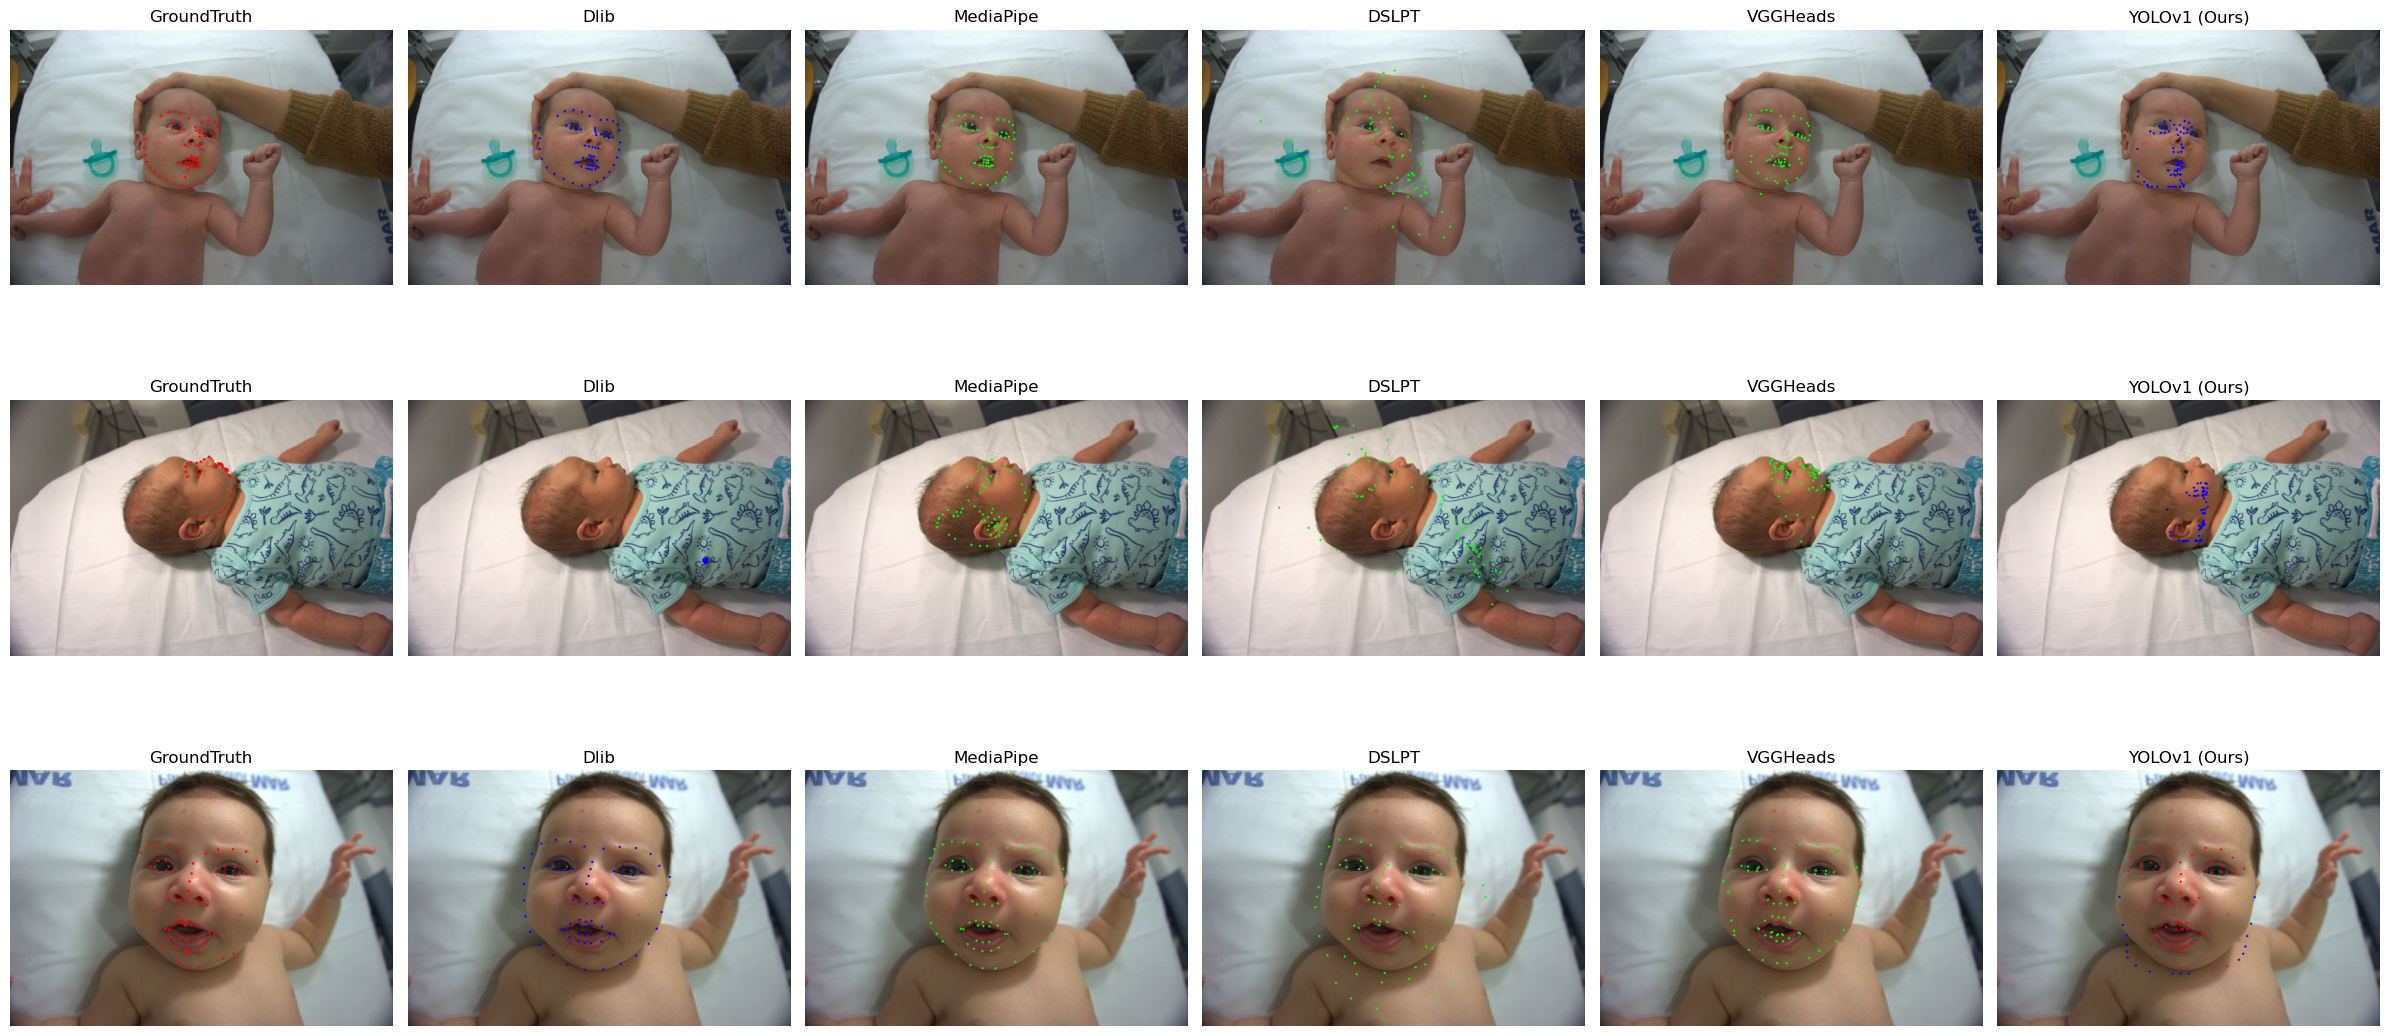

In [10]:
def dynamic_comparison_grid(directories, output_path, grid_size=(3, 4)):
    """
    Creates a grid of images for visual comparison of landmarks generated by different models.

    Args:
        directories (dict): A dictionary where keys are titles (e.g., 'GroundTruth', 'Dlib') and values are paths to directories containing images.
        output_path (str): Path to save the resulting grid image.
        grid_size (tuple): The number of rows and columns for the grid (default: 3x4).

    Returns:
        None
    """
    # Step 1: Filter image files for each directory
    filtered_files = {
        title: sorted([f for f in os.listdir(dir_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        for title, dir_path in directories.items()
    }

    # Step 2: Find common files across all directories
    common_files = set.intersection(*[set(files) for files in filtered_files.values()])
    common_files = sorted(common_files)  # Sort files for consistent order

    if not common_files:
        print("No common files found across the directories.")
        return

    # Step 3: Shuffle and select files for the grid
    random.shuffle(common_files)
    num_rows = grid_size[0]  # Number of rows
    files_to_display = common_files[:num_rows]

    rows, cols = grid_size
    fig, axs = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    axs = axs.flatten()

    # Step 4: Display each row with images from all directories
    for row_idx, file_name in enumerate(files_to_display):
        if row_idx * len(directories) >= len(axs):
            break

        # Load images from all directories for the current file
        images = [
            Image.open(os.path.join(dir_path, file_name))
            for dir_path in directories.values()
        ]
        titles = list(directories.keys())

        # Display images in the corresponding subplot
        for col_idx, (img, title) in enumerate(zip(images, titles)):
            ax_index = row_idx * len(directories) + col_idx
            if ax_index >= len(axs):
                break
            ax = axs[ax_index]
            ax.imshow(img)
            ax.axis('off')
            ax.set_title(title)

    # Step 5: Hide unused subplots
    used_subplots = len(files_to_display) * len(directories)
    for ax in axs[used_subplots:]:
        ax.axis('off')

    # Step 6: Final layout adjustments and save
    plt.tight_layout()
    plt.savefig(output_path)
    plt.show()

# Example usage
directories = {
    "GroundTruth": "/Users/jocareher/Downloads/plots_babyface72",
    "Dlib": "/Users/jocareher/Downloads/dlib_predictions/images",
    "MediaPipe": "/Users/jocareher/Downloads/mediapipe_68_lmks_predictions/images",
    "DSLPT": "/Users/jocareher/Downloads/results_dslpt/images",
    "VGGHeads": "/Users/jocareher/Downloads/vgg_results/images",
    "YOLOv1 (Ours)": "/Users/jocareher/Downloads/last_model_none_fixed/images"
    # Add more directories if needed
}

# Generate a grid with 3 rows and 4 columns
output_path = "/Users/jocareher/Downloads/output_grid.png"
dynamic_comparison_grid(directories, output_path, grid_size=(3, 6))


In [3]:
import imagehash

def calculate_image_hash(image_path: str) -> imagehash.ImageHash:
    """
    Calculate the perceptual hash of an image.

    Args:
        image_path (str): Path to the image file.

    Returns:
        imagehash.ImageHash: The perceptual hash of the image.
    """
    try:
        with Image.open(image_path) as img:
            return imagehash.average_hash(img)  # Calculate the average hash of the image
    except Exception as e:
        print(f"Error processing {image_path}: {e}")
        return None

def find_duplicate_images(dir_a: str, dir_b: str) -> Tuple[Dict[str, str], int]:
    """
    Find duplicate images between two directories using their hash values.

    Args:
        dir_a (str): Path to the first directory.
        dir_b (str): Path to the second directory.

    Returns:
        Tuple[Dict[str, str], int]: A dictionary mapping duplicate image names and the total count of duplicates.
    """
    # Dictionary to store image hashes and their corresponding file names
    hash_dict_a: Dict[imagehash.ImageHash, str] = {}
    hash_dict_b: Dict[imagehash.ImageHash, str] = {}

    # Dictionary to store duplicate image pairs
    duplicates: Dict[str, str] = {}

    # Process images in the first directory
    for filename in os.listdir(dir_a):
        file_path = os.path.join(dir_a, filename)
        if os.path.isfile(file_path):
            img_hash = calculate_image_hash(file_path)
            if img_hash:
                hash_dict_a[img_hash] = filename

    # Process images in the second directory
    for filename in os.listdir(dir_b):
        file_path = os.path.join(dir_b, filename)
        if os.path.isfile(file_path):
            img_hash = calculate_image_hash(file_path)
            if img_hash:
                hash_dict_b[img_hash] = filename

    # Compare hashes to find duplicates
    for img_hash, filename_a in hash_dict_a.items():
        if img_hash in hash_dict_b:
            filename_b = hash_dict_b[img_hash]
            duplicates[filename_a] = filename_b

    # Return the duplicates and their count
    return duplicates, len(duplicates)

def main(dir_a: str, dir_b: str) -> None:
    """
    Main function to compare images in two directories and print the results.

    Args:
        dir_a (str): Path to the first directory.
        dir_b (str): Path to the second directory.
    """
    # Find duplicate images
    duplicates, count = find_duplicate_images(dir_a, dir_b)

    # Print the results
    print(f"Images that are the same between {dir_a} and {dir_b} are:")
    for image_a, image_b in duplicates.items():
        print(f"{image_a} = {image_b}")

    print(f"Total number of duplicate images: {count}")


directory_a = "/Users/jocareher/Downloads/infant_face_test_set/images"  # Replace with the path to the first directory
directory_b = "/Users/jocareher/Library/CloudStorage/OneDrive-Personal/Educación/PhD_UPF_2023/datasets/obbabyface/train/images"  # Replace with the path to the second directory

# Run the main function
main(directory_a, directory_b)

Error processing /Users/jocareher/Library/CloudStorage/OneDrive-Personal/Educación/PhD_UPF_2023/datasets/obbabyface/train/images/.DS_Store: cannot identify image file '/Users/jocareher/Library/CloudStorage/OneDrive-Personal/Educación/PhD_UPF_2023/datasets/obbabyface/train/images/.DS_Store'
Images that are the same between /Users/jocareher/Downloads/infant_face_test_set/images and /Users/jocareher/Library/CloudStorage/OneDrive-Personal/Educación/PhD_UPF_2023/datasets/obbabyface/train/images are:
google-20.png = face_img_2061.jpg
google-58.png = face_img_6008.jpg
Total number of duplicate images: 2


In [5]:
import argparse
import shutil
from pathlib import Path
from typing import List, Tuple

import cv2
import pandas as pd
from tqdm import tqdm


def get_landmark_groups_68() -> List[List[int]]:
    """
    Return the standard connectivity groups for 68 facial landmarks.

    Returns:
        A list of landmark index groups describing the facial topology.
    """
    return [
        list(range(0, 17)),                         # Jaw
        list(range(17, 22)),                        # Right eyebrow
        list(range(22, 27)),                        # Left eyebrow
        list(range(27, 31)),                        # Nose bridge
        list(range(31, 36)),                        # Nose base
        [36, 37, 38, 39, 40, 41, 36],              # Right eye
        [42, 43, 44, 45, 46, 47, 42],              # Left eye
        [48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 48],  # Outer lip
        [60, 61, 62, 63, 64, 65, 66, 67, 60],      # Inner lip
    ]


def load_landmarks_from_row(row: pd.Series) -> List[Tuple[float, float]]:
    """
    Extract 68 landmark coordinates from one CSV row.

    Args:
        row: A pandas Series with columns gt-x0, gt-y0, ..., gt-x67, gt-y67.

    Returns:
        A list of 68 (x, y) landmark coordinates.
    """
    landmarks: List[Tuple[float, float]] = []

    for index in range(68):
        x_coord = float(row[f"gt-x{index}"])
        y_coord = float(row[f"gt-y{index}"])
        landmarks.append((x_coord, y_coord))

    return landmarks


def save_landmarks_txt(output_path: Path, landmarks: List[Tuple[float, float]]) -> None:
    """
    Save landmarks in the requested format:
        x1 y1
        x2 y2
        ...
        x68 y68

    Args:
        output_path: Path where the txt file will be saved.
        landmarks: List of 68 (x, y) landmark coordinates.
    """
    output_path.parent.mkdir(parents=True, exist_ok=True)

    with open(output_path, "w") as file:
        for x_coord, y_coord in landmarks:
            file.write(f"{x_coord} {y_coord}\n")


def draw_landmark_connections(
    image,
    landmarks: List[Tuple[float, float]],
    color: Tuple[int, int, int],
    line_thickness: int,
) -> None:
    """
    Draw the standard 68-landmark topology on an image.

    Args:
        image: OpenCV BGR image.
        landmarks: List of 68 landmark coordinates in absolute pixel space.
        color: BGR color used for points and lines.
        line_thickness: Thickness of the connection lines.
    """
    groups = get_landmark_groups_68()

    for group in groups:
        for start_index, end_index in zip(group[:-1], group[1:]):
            x1, y1 = landmarks[start_index]
            x2, y2 = landmarks[end_index]

            cv2.line(
                image,
                (int(round(x1)), int(round(y1))),
                (int(round(x2)), int(round(y2))),
                color,
                line_thickness,
            )


def draw_landmarks_overlay(
    image_path: Path,
    landmarks: List[Tuple[float, float]],
    output_path: Path,
    color: Tuple[int, int, int] = (255, 255, 0),
) -> None:
    """
    Draw landmarks plus topology on the original image and save it.

    Args:
        image_path: Path to the input image.
        landmarks: List of 68 (x, y) landmark coordinates.
        output_path: Path where the overlay image will be saved.
        color: BGR color for both landmarks and lines. Default is cyan.
    """
    image = cv2.imread(str(image_path))
    if image is None:
        raise FileNotFoundError(f"Could not load image: {image_path}")

    output_path.parent.mkdir(parents=True, exist_ok=True)

    height, width = image.shape[:2]
    diagonal = float((width ** 2 + height ** 2) ** 0.5)

    radius = max(4, min(int(diagonal * 0.0035), 10))
    line_thickness = max(1, int(radius * 0.6))

    draw_landmark_connections(
        image=image,
        landmarks=landmarks,
        color=color,
        line_thickness=line_thickness,
    )

    for x_coord, y_coord in landmarks:
        cv2.circle(
            image,
            (int(round(x_coord)), int(round(y_coord))),
            radius,
            color,
            thickness=-1,
        )

    cv2.imwrite(str(output_path), image)


def validate_landmarks_inside_image(
    landmarks: List[Tuple[float, float]],
    image_width: int,
    image_height: int,
) -> bool:
    """
    Check whether all landmarks lie inside image bounds.

    Args:
        landmarks: List of 68 (x, y) coordinates.
        image_width: Image width in pixels.
        image_height: Image height in pixels.

    Returns:
        True if all landmarks are inside bounds, False otherwise.
    """
    for x_coord, y_coord in landmarks:
        if not (0.0 <= x_coord < image_width and 0.0 <= y_coord < image_height):
            return False
    return True


def prepare_split_directories(output_root: Path) -> None:
    """
    Create the required output folder structure.

    Args:
        output_root: Output root directory.
    """
    required_dirs = [
        output_root / "train" / "images",
        output_root / "train" / "labels",
        output_root / "test" / "images",
        output_root / "test" / "labels",
        output_root / "all" / "images",
        output_root / "all" / "labels",
        output_root / "all" / "plots",
    ]

    for directory in required_dirs:
        directory.mkdir(parents=True, exist_ok=True)


def process_dataset(
    dataset_root: Path,
    output_root: Path,
    overlay_color: Tuple[int, int, int] = (255, 255, 0),
) -> None:
    """
    Prepare InfantFace into train/test/all with images, labels, and plots.

    This version flattens all files inside train/test/all and preserves
    only the original filename, without adding the image-set prefix.

    Args:
        dataset_root: Root directory containing:
            - images/
            - labels.csv
        output_root: Directory where the processed dataset will be saved.
        overlay_color: BGR color for overlays. Default is cyan.
    """
    labels_csv_path = dataset_root / "labels.csv"
    images_root = dataset_root / "images"

    if not labels_csv_path.exists():
        raise FileNotFoundError(f"labels.csv not found: {labels_csv_path}")
    if not images_root.exists():
        raise FileNotFoundError(f"images directory not found: {images_root}")

    dataframe = pd.read_csv(labels_csv_path)

    # Defensive check: ensure filenames are unique before flattening
    if dataframe["filename"].duplicated().any():
        duplicated_rows = dataframe[dataframe["filename"].duplicated(keep=False)].sort_values("filename")
        raise ValueError(
            "Duplicate filenames found in labels.csv. Flattening by filename only would cause collisions.\n"
            f"Examples:\n{duplicated_rows[['image-set', 'filename']].head(20)}"
        )

    prepare_split_directories(output_root)

    split_map = {
        "infanface-train": "train",
        "infanface-test": "test",
    }

    processed_count = 0
    missing_images = []
    suspicious_annotations = []

    for _, row in tqdm(dataframe.iterrows(), total=len(dataframe), desc="Preparing InfantFace"):
        image_set = str(row["image-set"])
        filename = str(row["filename"])
        partition = str(row["partition"])

        if partition not in split_map:
            continue

        split_name = split_map[partition]
        source_image_path = images_root / image_set / filename

        if not source_image_path.exists():
            missing_images.append(str(source_image_path))
            continue

        image = cv2.imread(str(source_image_path))
        if image is None:
            missing_images.append(str(source_image_path))
            continue

        image_height, image_width = image.shape[:2]
        landmarks = load_landmarks_from_row(row)

        if not validate_landmarks_inside_image(
            landmarks=landmarks,
            image_width=image_width,
            image_height=image_height,
        ):
            suspicious_annotations.append(str(source_image_path))

        split_image_path = output_root / split_name / "images" / filename
        split_label_path = output_root / split_name / "labels" / f"{Path(filename).stem}.txt"

        all_image_path = output_root / "all" / "images" / filename
        all_label_path = output_root / "all" / "labels" / f"{Path(filename).stem}.txt"
        all_plot_path = output_root / "all" / "plots" / filename

        shutil.copy2(source_image_path, split_image_path)
        shutil.copy2(source_image_path, all_image_path)

        save_landmarks_txt(split_label_path, landmarks)
        save_landmarks_txt(all_label_path, landmarks)

        draw_landmarks_overlay(
            image_path=source_image_path,
            landmarks=landmarks,
            output_path=all_plot_path,
            color=overlay_color,
        )

        processed_count += 1

    print("\n=== InfantFace Preparation Summary ===")
    print(f"Total rows in CSV          : {len(dataframe)}")
    print(f"Successfully processed     : {processed_count}")
    print(f"Missing / unreadable imgs  : {len(missing_images)}")
    print(f"Suspicious annotations     : {len(suspicious_annotations)}")

    if missing_images:
        print("\nMissing image paths:")
        for path in missing_images:
            print(path)

    if suspicious_annotations:
        print("\nImages with suspicious annotations (at least one landmark outside image bounds):")
        for path in suspicious_annotations:
            print(path)




In [6]:
dataset_root = Path("/Users/jocareher/Downloads/infanface-public")  # Replace with the actual dataset root path
output_root = Path("/Users/jocareher/Downloads/infanface_prepared")
color_bgr = (0, 0, 255)  # Cyan color for overlays in BGR format
process_dataset(dataset_root, output_root, color_bgr)

Preparing InfantFace:  26%|██▌       | 105/410 [00:02<00:06, 47.94it/s]libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
Preparing InfantFace:  27%|██▋       | 110/410 [00:02<00:07, 38.23it/s]libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
Preparing InfantFace:  28%|██▊       | 115/410 [00:02<00:11, 24.98it/s]libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
Preparing InfantFace:  30%|███       | 123/410 [00:03<00:10, 26.74it/s]libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
Preparing InfantFace:  37%|███▋      | 152/410 [00:04<00:10, 23.60it/s]libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
Preparing InfantFace:  39%|███▉  


=== InfantFace Preparation Summary ===
Total rows in CSV          : 410
Successfully processed     : 410
Missing / unreadable imgs  : 0
Suspicious annotations     : 5

Images with suspicious annotations (at least one landmark outside image bounds):
/Users/jocareher/Downloads/infanface-public/images/google/google-73.png
/Users/jocareher/Downloads/infanface-public/images/youtube2/004.jpg
/Users/jocareher/Downloads/infanface-public/images/youtube2/044.jpg
/Users/jocareher/Downloads/infanface-public/images/youtube2/049.jpg
/Users/jocareher/Downloads/infanface-public/images/youtube2/053.jpg


In [6]:
from pathlib import Path
from typing import Dict, List, Optional, Tuple
import json
import shutil

import pandas as pd


ORIENTATION_LABEL_TO_CLASS_IDX = {
    "Left_sideview": 0,
    "3/4_left_sideview": 1,
    "Frontal": 2,
    "3/4_rigth_sideview": 3,
    "Right_sideview": 4,
}


def detect_existing_orientation_header(label_path: Path) -> bool:
    """
    Check whether a landmark label file already starts with a class_idx header.

    A valid header is assumed to be a first non-empty line containing exactly one
    integer between 0 and 4.

    Args:
        label_path: Path to the landmark label file.

    Returns:
        True if the file appears to already contain a class_idx header, otherwise False.
    """
    with open(label_path, "r", encoding="utf-8") as file:
        for raw_line in file:
            line = raw_line.strip()
            if not line:
                continue

            parts = line.split()
            if len(parts) == 1:
                try:
                    value = int(parts[0])
                    return 0 <= value <= 4
                except ValueError:
                    return False

            return False

    return False


def extract_stem_from_labelstudio_image_path(image_field: str) -> str:
    """
    Extract the image stem from a Label Studio image path.

    Example:
        '/data/local-files/?d=.../face_bcn_00.JPG' -> 'face_bcn_00'

    Args:
        image_field: The 'image' field from one Label Studio task.

    Returns:
        The filename stem.
    """
    normalized = image_field.replace("\\/", "/")
    filename = Path(normalized).name
    return Path(filename).stem


def build_labelstudio_orientation_index(
    json_path: Path,
) -> Tuple[Dict[str, Dict], List[str]]:
    """
    Build an index from Label Studio JSON keyed by image stem.

    The function reads the first valid rectangle label per image and maps it to
    class_idx using ORIENTATION_LABEL_TO_CLASS_IDX. Labels such as 'doubt' are
    ignored and reported.

    Args:
        json_path: Path to the Label Studio exported JSON file.

    Returns:
        A tuple containing:
        - orientation_index: Dictionary keyed by image stem with metadata
        - conflicts: A list of warnings/conflicts found while indexing
    """
    with open(json_path, "r", encoding="utf-8") as file:
        tasks = json.load(file)

    orientation_index: Dict[str, Dict] = {}
    conflicts: List[str] = []

    for task in tasks:
        image_field = task.get("image")
        if not image_field:
            conflicts.append(f"Task without image field: {task.get('id')}")
            continue

        stem = extract_stem_from_labelstudio_image_path(str(image_field))
        labels = task.get("label", [])

        selected_label_name: Optional[str] = None

        for label_entry in labels:
            rectangle_labels = label_entry.get("rectanglelabels", [])
            if not rectangle_labels:
                continue

            candidate = rectangle_labels[0]

            if candidate == "doubt":
                continue

            if candidate in ORIENTATION_LABEL_TO_CLASS_IDX:
                selected_label_name = candidate
                break

        if selected_label_name is None:
            conflicts.append(
                f"No valid orientation label found for '{stem}' in task {task.get('id')}"
            )
            continue

        class_idx = ORIENTATION_LABEL_TO_CLASS_IDX[selected_label_name]

        if stem in orientation_index:
            previous = orientation_index[stem]
            if previous["class_idx"] != class_idx:
                conflicts.append(
                    f"Conflicting orientation for '{stem}': "
                    f"{previous['label_name']} ({previous['class_idx']}) vs "
                    f"{selected_label_name} ({class_idx})"
                )
            else:
                conflicts.append(
                    f"Duplicate entry with same orientation for '{stem}'"
                )
            continue

        orientation_index[stem] = {
            "class_idx": class_idx,
            "label_name": selected_label_name,
            "task_id": task.get("id"),
            "annotation_id": task.get("annotation_id"),
            "image_field": image_field,
        }

    return orientation_index, conflicts


def add_orientation_to_landmark_labels_from_labelstudio(
    labelstudio_json_path: str,
    lmk_root: str,
    output_labels_dir: Optional[str] = None,
    unmatched_dir: Optional[str] = None,
    overwrite_existing_header: bool = False,
    report_csv_path: Optional[str] = None,
) -> Dict[str, object]:
    """
    Add class_idx orientation headers to landmark annotation files by matching
    them against a Label Studio JSON export.

    Landmark label input format:
        x1 y1 v1
        ...
        xn yn vn

    Landmark label output format:
        class_idx
        x1 y1 v1
        ...
        xn yn vn

    Unmatched landmark files are copied unchanged into an unmatched directory.

    Args:
        labelstudio_json_path: Path to the Label Studio JSON export.
        lmk_root: Root directory of the landmark dataset.
        output_labels_dir: Directory where modified labels will be written.
            If None, a new directory named 'labels_with_orientation' is created
            inside the landmark dataset root.
        unmatched_dir: Directory where unmatched original label files will be copied.
            If None, a new directory named 'unmatched' is created inside the landmark dataset root.
        overwrite_existing_header: If True, overwrite files that already appear
            to contain a class_idx header. If False, they are skipped.
        report_csv_path: Optional output path for a CSV report. If None, a default
            file named 'orientation_merge_report.csv' is created inside lmk_root.

    Returns:
        A report dictionary summarizing the operation.
    """
    json_path = Path(labelstudio_json_path)
    lmk_root_path = Path(lmk_root)
    lmk_labels_dir = lmk_root_path / "labels"

    if output_labels_dir is None:
        output_labels_path = lmk_root_path / "labels_with_orientation"
    else:
        output_labels_path = Path(output_labels_dir)

    if unmatched_dir is None:
        unmatched_path = lmk_root_path / "unmatched"
    else:
        unmatched_path = Path(unmatched_dir)

    if report_csv_path is None:
        report_csv = lmk_root_path / "orientation_merge_report.csv"
    else:
        report_csv = Path(report_csv_path)

    if not json_path.exists():
        raise FileNotFoundError(f"Label Studio JSON not found: {json_path}")
    if not lmk_root_path.exists():
        raise FileNotFoundError(f"Landmark dataset root not found: {lmk_root_path}")
    if not lmk_labels_dir.exists():
        raise FileNotFoundError(f"Landmark labels directory not found: {lmk_labels_dir}")

    output_labels_path.mkdir(parents=True, exist_ok=True)
    unmatched_path.mkdir(parents=True, exist_ok=True)
    report_csv.parent.mkdir(parents=True, exist_ok=True)

    orientation_index, json_conflicts = build_labelstudio_orientation_index(json_path)

    matched_count = 0
    unmatched_count = 0
    skipped_existing_header = 0
    written_count = 0
    unmatched_copied_count = 0

    unmatched_files: List[str] = []
    matched_files: List[str] = []
    skipped_files: List[str] = []

    report_rows: List[Dict[str, object]] = []

    for lmk_label_path in sorted(lmk_labels_dir.glob("*.txt")):
        stem = lmk_label_path.stem
        output_path = output_labels_path / lmk_label_path.name
        unmatched_output_path = unmatched_path / lmk_label_path.name

        already_has_header = detect_existing_orientation_header(lmk_label_path)

        row_data: Dict[str, object] = {
            "filename": lmk_label_path.name,
            "stem": stem,
            "input_label_path": str(lmk_label_path),
            "output_label_path": str(output_path),
            "unmatched_output_path": str(unmatched_output_path),
            "already_had_header": already_has_header,
            "matched": False,
            "class_idx": None,
            "label_name": None,
            "task_id": None,
            "annotation_id": None,
            "image_field": None,
            "written_output": False,
            "copied_to_unmatched": False,
            "status": None,
        }

        if already_has_header and not overwrite_existing_header:
            skipped_existing_header += 1
            skipped_files.append(lmk_label_path.name)
            row_data["status"] = "skipped_existing_header"
            report_rows.append(row_data)
            continue

        if stem not in orientation_index:
            unmatched_count += 1
            unmatched_files.append(lmk_label_path.name)

            shutil.copy2(lmk_label_path, unmatched_output_path)
            unmatched_copied_count += 1

            row_data["copied_to_unmatched"] = True
            row_data["status"] = "unmatched_copied"
            report_rows.append(row_data)
            continue

        orientation_info = orientation_index[stem]
        class_idx = orientation_info["class_idx"]

        row_data["matched"] = True
        row_data["class_idx"] = class_idx
        row_data["label_name"] = orientation_info["label_name"]
        row_data["task_id"] = orientation_info["task_id"]
        row_data["annotation_id"] = orientation_info["annotation_id"]
        row_data["image_field"] = orientation_info["image_field"]

        with open(lmk_label_path, "r", encoding="utf-8") as file:
            original_lines = [line.rstrip("\n") for line in file]

        non_empty_lines = [line for line in original_lines if line.strip()]

        with open(output_path, "w", encoding="utf-8") as file:
            file.write(f"{class_idx}\n")
            for line in non_empty_lines:
                file.write(f"{line}\n")

        matched_count += 1
        written_count += 1
        matched_files.append(lmk_label_path.name)

        row_data["written_output"] = True
        row_data["status"] = "matched_written"
        report_rows.append(row_data)

    report_df = pd.DataFrame(report_rows)
    report_df.to_csv(report_csv, index=False)

    report = {
        "orientation_index_size": len(orientation_index),
        "json_conflicts": json_conflicts,
        "matched_count": matched_count,
        "unmatched_count": unmatched_count,
        "written_count": written_count,
        "unmatched_copied_count": unmatched_copied_count,
        "skipped_existing_header": skipped_existing_header,
        "matched_files": matched_files,
        "unmatched_files": unmatched_files,
        "skipped_files": skipped_files,
        "output_labels_dir": str(output_labels_path),
        "unmatched_dir": str(unmatched_path),
        "report_csv_path": str(report_csv),
    }

    print("=== Orientation Merge Report (Label Studio JSON) ===")
    print(f"Indexed JSON annotations         : {report['orientation_index_size']}")
    print(f"Matched landmark annotations     : {report['matched_count']}")
    print(f"Unmatched landmark annotations   : {report['unmatched_count']}")
    print(f"Written output files             : {report['written_count']}")
    print(f"Copied unmatched files           : {report['unmatched_copied_count']}")
    print(f"Skipped existing header files    : {report['skipped_existing_header']}")
    print(f"JSON conflicts / warnings        : {len(report['json_conflicts'])}")
    print(f"Output labels directory          : {report['output_labels_dir']}")
    print(f"Unmatched directory              : {report['unmatched_dir']}")
    print(f"Report CSV path                  : {report['report_csv_path']}")

    if report["unmatched_files"]:
        print("\nLandmark files without JSON match:")
        for name in report["unmatched_files"]:
            print(f"  {name}")

    if report["json_conflicts"]:
        print("\nJSON conflicts / warnings:")
        for message in report["json_conflicts"]:
            print(f"  {message}")

    return report

In [7]:
report = add_orientation_to_landmark_labels_from_labelstudio(
    labelstudio_json_path="/Users/jocareher/Downloads/project-3-at-2026-04-20-13-41-a54589c2.json",
    lmk_root="/Users/jocareher/Documents/baby_face_72",
)

=== Orientation Merge Report (Label Studio JSON) ===
Indexed JSON annotations         : 623
Matched landmark annotations     : 299
Unmatched landmark annotations   : 12
Written output files             : 299
Copied unmatched files           : 12
Skipped existing header files    : 0
JSON conflicts / warnings        : 45
Output labels directory          : /Users/jocareher/Documents/baby_face_72/labels_with_orientation
Unmatched directory              : /Users/jocareher/Documents/baby_face_72/unmatched
Report CSV path                  : /Users/jocareher/Documents/baby_face_72/orientation_merge_report.csv

Landmark files without JSON match:
  face_bcn_125.txt
  face_bcn_128.txt
  face_bcn_129.txt
  face_bcn_163.txt
  face_bcn_226.txt
  face_bcn_232.txt
  face_bcn_240.txt
  face_bcn_243.txt
  face_bcn_288.txt
  face_bcn_292.txt
  face_bcn_31.txt
  face_bcn_365.txt

JSON conflicts / warnings:
  No valid orientation label found for 'face_bcn_125' in task 8672
  No valid orientation label foun

In [1]:
from pathlib import Path
from typing import Dict, List, Optional, Tuple
import shutil
import pandas as pd


def read_newborn_class_idx(prediction_txt_path: Path) -> Optional[int]:
    """
    Read the first valid class_idx from a NewBORN prediction file.

    Expected line format:
        class_idx x1 y1 x2 y2 x3 y3 x4 y4 angle

    If multiple detections are present, the first valid detection is used.

    Args:
        prediction_txt_path: Path to the NewBORN prediction txt file.

    Returns:
        The first valid class_idx in [0, 4], or None if no valid detection exists.
    """
    with open(prediction_txt_path, "r", encoding="utf-8") as file:
        for raw_line in file:
            line = raw_line.strip()
            if not line:
                continue

            parts = line.split()
            if len(parts) < 10:
                continue

            try:
                class_idx = int(float(parts[0]))
            except ValueError:
                continue

            if 0 <= class_idx <= 4:
                return class_idx

    return None


def build_newborn_prediction_index(
    newborn_predictions_dir: Path,
) -> Tuple[Dict[str, Dict[str, object]], List[str]]:
    """
    Build an index mapping image stem -> class_idx from NewBORN prediction files.

    Args:
        newborn_predictions_dir: Directory containing one .txt prediction file per image.

    Returns:
        A tuple containing:
        - prediction_index: dictionary keyed by stem with:
            {
                "class_idx": int,
                "prediction_path": str,
            }
        - warnings: list of warning messages
    """
    prediction_index: Dict[str, Dict[str, object]] = {}
    warnings: List[str] = []

    if not newborn_predictions_dir.exists():
        raise FileNotFoundError(f"NewBORN prediction directory not found: {newborn_predictions_dir}")

    for prediction_txt in sorted(newborn_predictions_dir.glob("*.txt")):
        stem = prediction_txt.stem
        class_idx = read_newborn_class_idx(prediction_txt)

        if class_idx is None:
            warnings.append(f"No valid class_idx found in prediction file: {prediction_txt}")
            continue

        if stem in prediction_index:
            warnings.append(
                f"Duplicate prediction stem encountered: {stem} ({prediction_txt})"
            )
            continue

        prediction_index[stem] = {
            "class_idx": class_idx,
            "prediction_path": str(prediction_txt),
        }

    return prediction_index, warnings


def infanface_label_has_class_header(label_path: Path) -> bool:
    """
    Check whether an InfantFace landmark label already starts with a class header.

    Args:
        label_path: Path to the label file.

    Returns:
        True if the first non-empty line contains a single integer in [0, 4].
    """
    with open(label_path, "r", encoding="utf-8") as file:
        for raw_line in file:
            line = raw_line.strip()
            if not line:
                continue

            parts = line.split()
            if len(parts) != 1:
                return False

            try:
                value = int(parts[0])
            except ValueError:
                return False

            return 0 <= value <= 4

    return False


def update_infanface_partition_labels(
    labels_dir: Path,
    prediction_index: Dict[str, Dict[str, object]],
    overwrite_existing_header: bool = False,
) -> Tuple[List[Dict[str, object]], List[str]]:
    """
    Update one InfantFace labels directory by prepending class_idx from NewBORN predictions.

    Input label format:
        x1 y1
        ...
        x68 y68

    Output label format:
        class_idx
        x1 y1
        ...
        x68 y68

    Args:
        labels_dir: Directory containing InfantFace label txt files.
        prediction_index: Mapping from image stem to NewBORN class_idx.
        overwrite_existing_header: If True, overwrite labels that already contain a class header.

    Returns:
        A tuple containing:
        - report_rows: list of per-file report dictionaries
        - warnings: list of warnings
    """
    report_rows: List[Dict[str, object]] = []
    warnings: List[str] = []

    if not labels_dir.exists():
        warnings.append(f"Labels directory does not exist: {labels_dir}")
        return report_rows, warnings

    for label_path in sorted(labels_dir.glob("*.txt")):
        stem = label_path.stem
        already_has_header = infanface_label_has_class_header(label_path)

        row = {
            "partition_labels_dir": str(labels_dir),
            "filename": label_path.name,
            "stem": stem,
            "label_path": str(label_path),
            "matched_prediction": False,
            "class_idx": None,
            "already_had_header": already_has_header,
            "updated": False,
            "status": None,
            "prediction_path": None,
        }

        if already_has_header and not overwrite_existing_header:
            row["status"] = "skipped_existing_header"
            report_rows.append(row)
            continue

        prediction_info = prediction_index.get(stem)
        if prediction_info is None:
            row["status"] = "prediction_not_found"
            report_rows.append(row)
            continue

        class_idx = int(prediction_info["class_idx"])
        prediction_path = str(prediction_info["prediction_path"])

        with open(label_path, "r", encoding="utf-8") as file:
            lines = [line.rstrip("\n") for line in file if line.strip()]

        if already_has_header and overwrite_existing_header:
            # Remove old header and keep the remaining x y lines.
            lines = lines[1:]

        with open(label_path, "w", encoding="utf-8") as file:
            file.write(f"{class_idx}\n")
            for line in lines:
                file.write(f"{line}\n")

        row["matched_prediction"] = True
        row["class_idx"] = class_idx
        row["updated"] = True
        row["status"] = "updated"
        row["prediction_path"] = prediction_path
        report_rows.append(row)

    return report_rows, warnings


def add_newborn_class_idx_to_infanface(
    infanface_root: str,
    newborn_predictions_dir: str,
    overwrite_existing_header: bool = False,
    report_csv_path: Optional[str] = None,
) -> Dict[str, object]:
    """
    Update InfantFace labels in all/train/test partitions by prepending the class_idx
    obtained from NewBORN predictions.

    Expected InfantFace structure:
        root/
        ├── all/
        │   ├── images/
        │   ├── labels/
        │   └── plots/
        ├── test/
        │   ├── images/
        │   └── labels/
        └── train/
            ├── images/
            └── labels/

    Expected NewBORN predictions structure:
        newborn_predictions_dir/
        ├── image1.txt
        ├── image2.txt
        └── ...

    Input InfantFace label format:
        x1 y1
        ...
        x68 y68

    Output InfantFace label format:
        class_idx
        x1 y1
        ...
        x68 y68

    Args:
        infanface_root: Root directory of the prepared InfantFace dataset.
        newborn_predictions_dir: Directory containing NewBORN prediction txt files.
        overwrite_existing_header: If True, overwrite labels that already contain a class header.
        report_csv_path: Optional CSV report path. If None, saves under infanface_root.

    Returns:
        A dictionary summarizing the operation.
    """
    infanface_root_path = Path(infanface_root)
    newborn_predictions_path = Path(newborn_predictions_dir)

    if not infanface_root_path.exists():
        raise FileNotFoundError(f"InfantFace root not found: {infanface_root_path}")

    if report_csv_path is None:
        report_csv = infanface_root_path / "newborn_classidx_merge_report.csv"
    else:
        report_csv = Path(report_csv_path)

    report_csv.parent.mkdir(parents=True, exist_ok=True)

    prediction_index, prediction_warnings = build_newborn_prediction_index(newborn_predictions_path)

    all_rows: List[Dict[str, object]] = []
    all_warnings: List[str] = list(prediction_warnings)

    partitions = ["all", "train", "test"]

    for partition_name in partitions:
        labels_dir = infanface_root_path / partition_name / "labels"
        rows, warnings = update_infanface_partition_labels(
            labels_dir=labels_dir,
            prediction_index=prediction_index,
            overwrite_existing_header=overwrite_existing_header,
        )

        for row in rows:
            row["partition"] = partition_name

        all_rows.extend(rows)
        all_warnings.extend(warnings)

    report_df = pd.DataFrame(all_rows)
    report_df.to_csv(report_csv, index=False)

    total_files = len(report_df)
    updated_count = int((report_df["status"] == "updated").sum()) if total_files > 0 else 0
    skipped_count = int((report_df["status"] == "skipped_existing_header").sum()) if total_files > 0 else 0
    not_found_count = int((report_df["status"] == "prediction_not_found").sum()) if total_files > 0 else 0

    missing_prediction_files = []
    if total_files > 0:
        missing_prediction_files = (
            report_df.loc[report_df["status"] == "prediction_not_found", "filename"]
            .astype(str)
            .tolist()
        )

    summary = {
        "infanface_root": str(infanface_root_path),
        "newborn_predictions_dir": str(newborn_predictions_path),
        "prediction_index_size": len(prediction_index),
        "total_label_files_seen": total_files,
        "updated_count": updated_count,
        "skipped_existing_header_count": skipped_count,
        "prediction_not_found_count": not_found_count,
        "warnings": all_warnings,
        "missing_prediction_files": missing_prediction_files,
        "report_csv_path": str(report_csv),
    }

    print("=== InfantFace class_idx injection report ===")
    print(f"Prediction files indexed           : {summary['prediction_index_size']}")
    print(f"Total label files seen             : {summary['total_label_files_seen']}")
    print(f"Updated label files                : {summary['updated_count']}")
    print(f"Skipped existing header files      : {summary['skipped_existing_header_count']}")
    print(f"Prediction not found               : {summary['prediction_not_found_count']}")
    print(f"Warnings                           : {len(summary['warnings'])}")
    print(f"Report CSV                         : {summary['report_csv_path']}")

    if missing_prediction_files:
        print("\nFiles without matching NewBORN prediction:")
        for filename in missing_prediction_files:
            print(f"  {filename}")

    if all_warnings:
        print("\nWarnings:")
        for warning in all_warnings:
            print(f"  {warning}")

    return summary

In [2]:
summary = add_newborn_class_idx_to_infanface(
    infanface_root="/Users/jocareher/Documents/infanface_adapted",
    newborn_predictions_dir="/Users/jocareher/Documents/infanface_inference/labels",
    overwrite_existing_header=True,
    report_csv_path="/Users/jocareher/Documents/infanface_adapted/classidx_merge_report.csv",
)

=== InfantFace class_idx injection report ===
Prediction files indexed           : 405
Total label files seen             : 815
Updated label files                : 810
Skipped existing header files      : 0
Prediction not found               : 5
Warnings                           : 0
Report CSV                         : /Users/jocareher/Documents/infanface_adapted/classidx_merge_report.csv

Files without matching NewBORN prediction:
  004.txt
  044.txt
  049.txt
  053.txt
  google-73.txt
